<a href="https://colab.research.google.com/github/sepehriravani/explainable-predictive-maintenance/blob/main/notebooks/03_modeling_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Predictive Maintenance

## 03 — Modeling and Evaluation

In this notebook, I train and evaluate a Logistic Regression model for predicting machine failures.

The preprocessing steps are repeated so that this notebook can run independently.


In [5]:
!pip install -q ucimlrepo

In [6]:
import pandas as pd

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
data = fetch_ucirepo(id=601)

X = data.data.features
y = data.data.targets

target = y["Machine failure"]

In [8]:
X.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [9]:
target.value_counts()

,count
Machine failure,
0,9661
1,339


In [10]:
features_encoded = pd.get_dummies(
    X,
    columns=["Type"],
    dtype=int
)

In [11]:
features_encoded.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    features_encoded,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

In [13]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (8000, 8)
X_test: (2000, 8)


In [14]:
numeric_columns = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

In [15]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

In [16]:
X_train_scaled[numeric_columns].describe().round(2)

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
count,8000.00,8000.00,8000.00,8000.00,8000.00
mean,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-2.36,-2.91,-2.05,-3.61,-1.69
25%,-0.85,-0.82,-0.65,-0.68,-0.86
50%,0.05,0.06,-0.20,0.01,-0.01
75%,0.75,0.74,0.41,0.68,0.87
max,2.25,2.56,7.44,3.65,2.28


## Baseline Model

Before training a machine learning model, I create a simple baseline for comparison.

Because most machines in the dataset did not fail, the baseline predicts **no failure for every test sample**.

A useful machine learning model should perform better than this simple strategy, especially in detecting actual failures.


In [17]:
baseline_predictions = [0] * len(y_test)

In [18]:
from sklearn.metrics import accuracy_score

In [19]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.966


In [20]:
from sklearn.metrics import confusion_matrix

In [21]:
baseline_matrix = confusion_matrix(
    y_test,
    baseline_predictions
)

baseline_matrix

array([[1932,    0],
       [  68,    0]])

In [22]:
baseline_matrix_df = pd.DataFrame(
    baseline_matrix,
    index=["Actual: No failure", "Actual: Failure"],
    columns=["Predicted: No failure", "Predicted: Failure"]
)

baseline_matrix_df

,Predicted: No failure,Predicted: Failure
Actual: No failure,1932,0
Actual: Failure,68,0


In [23]:
from sklearn.metrics import recall_score

baseline_recall = recall_score(
    y_test,
    baseline_predictions
)

print("Baseline recall:", baseline_recall)

Baseline recall: 0.0


### Baseline Results

The baseline achieves high accuracy because most observations belong to the no-failure class.

However, its recall is zero because it does not detect any of the actual machine failures.

This result shows that accuracy alone is misleading for this imbalanced dataset. Therefore, recall, precision, F1-score, and the confusion matrix will also be used to evaluate the main model.


## Logistic Regression Model

A Logistic Regression model is trained to predict machine failures.

Because failure cases are much less common, balanced class weights are used to give more importance to the minority class.


In [24]:
from sklearn.linear_model import LogisticRegression

In [30]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
)

In [31]:
logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [32]:
logistic_predictions = logistic_model.predict(
    X_test_scaled
)

In [33]:
logistic_predictions[:20]

array([1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0])

In [34]:
pd.Series(logistic_predictions).value_counts()

,count
0,1605
1,395


## Model Evaluation

The Logistic Regression model is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

These metrics are especially important because the dataset is highly imbalanced.


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [36]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

In [37]:
print("Logistic Regression accuracy:", logistic_accuracy)
print("Logistic Regression precision:", logistic_precision)
print("Logistic Regression recall:", logistic_recall)
print("Logistic Regression F1-score:", logistic_f1)

Logistic Regression accuracy: 0.8245
Logistic Regression precision: 0.14177215189873418
Logistic Regression recall: 0.8235294117647058
Logistic Regression F1-score: 0.24190064794816415


### Evaluation Results

The Logistic Regression model detects approximately 82% of the actual machine failures, which is a significant improvement over the baseline model.

However, precision is low, meaning that many normal machines are incorrectly classified as failures. This is partly caused by the use of balanced class weights, which makes the model prioritize detecting the minority failure class.

The model therefore provides high recall at the cost of a large number of false alarms.


### Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for both classes.

False negatives represent failures that the model missed, while false positives represent unnecessary failure warnings.


In [38]:
logistic_matrix = confusion_matrix(
    y_test,
    logistic_predictions
)

logistic_matrix_df = pd.DataFrame(
    logistic_matrix,
    index=["Actual: No failure", "Actual: Failure"],
    columns=["Predicted: No failure", "Predicted: Failure"]
)

logistic_matrix_df

,Predicted: No failure,Predicted: Failure
Actual: No failure,1593,339
Actual: Failure,12,56


In [39]:
true_negative, false_positive, false_negative, true_positive = (
    logistic_matrix.ravel()
)

In [40]:
print("True negatives:", true_negative)
print("False positives:", false_positive)
print("False negatives:", false_negative)
print("True positives:", true_positive)

True negatives: 1593
False positives: 339
False negatives: 12
True positives: 56


## Model Explainability

The coefficients of the Logistic Regression model are examined to understand how each feature affects the prediction.

Positive coefficients increase the predicted likelihood of machine failure, while negative coefficients decrease it.


In [41]:
coefficient_table = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficient_table

,Feature,Coefficient
0,Air temperature,1.780761
1,Process temperature,-1.230948
2,Rotational speed,1.730631
3,Torque,2.405050
4,Tool wear,0.860512
5,Type_H,-0.549098
6,Type_L,-0.082376
7,Type_M,-0.545609


In [42]:
logistic_model.coef_

array([[ 1.78076074, -1.23094774,  1.73063094,  2.4050496 ,  0.86051193,
        -0.54909839, -0.08237562, -0.54560905]])

In [45]:
logistic_model.coef_[0]

array([ 1.78076074, -1.23094774,  1.73063094,  2.4050496 ,  0.86051193,
       -0.54909839, -0.08237562, -0.54560905])

In [46]:
coefficient_table["Absolute coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "Absolute coefficient",
    ascending=False
)

coefficient_table

,Feature,Coefficient,Absolute coefficient
3,Torque,2.405050,2.405050
0,Air temperature,1.780761,1.780761
2,Rotational speed,1.730631,1.730631
1,Process temperature,-1.230948,1.230948
4,Tool wear,0.860512,0.860512
5,Type_H,-0.549098,0.549098
7,Type_M,-0.545609,0.545609
6,Type_L,-0.082376,0.082376


### Feature Importance Based on Coefficients

The learned coefficients are visualized to compare the direction and strength of each feature's effect on machine failure predictions.

Larger absolute coefficients indicate a stronger influence on the model.


In [47]:
import matplotlib.pyplot as plt

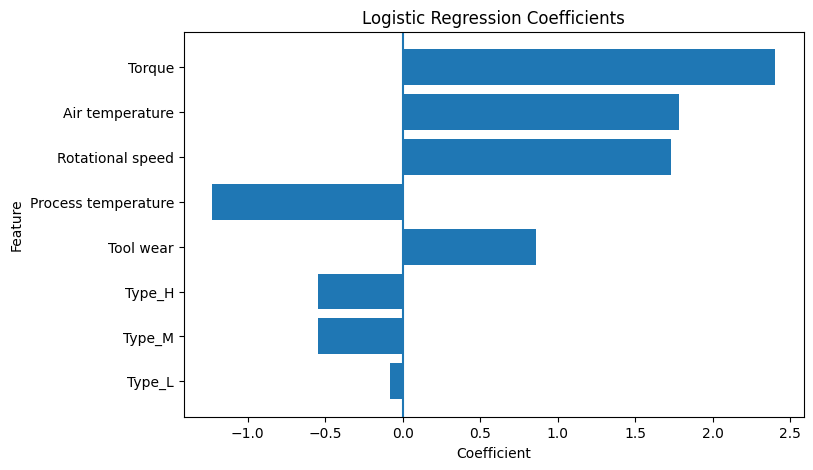

In [51]:
plt.figure(figsize=(8, 5))

plt.barh(
    coefficient_table["Feature"],
    coefficient_table["Coefficient"]
)

plt.axvline(0)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

## Model Comparison

The baseline model achieves high accuracy but fails to detect any machine failures.

Logistic Regression has lower accuracy, but it detects most of the actual failures. Therefore, recall is more informative than accuracy for this imbalanced dataset.


In [53]:
comparison_table["Accuracy"] = (
    comparison_table["Accuracy"] * 100
).round(2)

comparison_table["Recall"] = (
    comparison_table["Recall"] * 100
).round(2)

comparison_table

,Model,Accuracy,Recall
0,Baseline,96.60,0.00
1,Logistic Regression,82.45,82.35


## Class Weight Comparison

A second Logistic Regression model is trained without balanced class weights.

The two models are compared to examine how class weighting affects failure detection and false alarms.


In [61]:
unbalanced_model = LogisticRegression(
    max_iter=1000
)

unbalanced_model.fit(
    X_train_scaled,
    y_train
)

unbalanced_predictions = unbalanced_model.predict(
    X_test_scaled
)

In [62]:
unbalanced_accuracy = accuracy_score(
    y_test,
    unbalanced_predictions
)

unbalanced_precision = precision_score(
    y_test,
    unbalanced_predictions
)

unbalanced_recall = recall_score(
    y_test,
    unbalanced_predictions
)

unbalanced_f1 = f1_score(
    y_test,
    unbalanced_predictions
)

In [63]:
weight_comparison = pd.DataFrame({
    "Model": [
        "Without balanced weights",
        "With balanced weights"
    ],
    "Accuracy": [
        unbalanced_accuracy,
        logistic_accuracy
    ],
    "Precision": [
        unbalanced_precision,
        logistic_precision
    ],
    "Recall": [
        unbalanced_recall,
        logistic_recall
    ],
    "F1-score": [
        unbalanced_f1,
        logistic_f1
    ]
})

weight_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Without balanced weights,0.968,0.636,0.103,0.177
1,With balanced weights,0.824,0.142,0.824,0.242


### Class Weight Comparison Result

The model without balanced class weights achieves higher accuracy and precision, but it detects only about 10% of the actual machine failures.

The model with balanced class weights detects approximately 82% of the failures, although it produces more false alarms.

For predictive maintenance, missing a real failure can be more costly than generating an unnecessary warning. Therefore, the balanced Logistic Regression model is selected as the main model.


## Error Analysis

The model errors are examined to better understand false negatives and false positives.

False negatives are actual failures that the model missed. False positives are normal machines that the model incorrectly classified as failures.


In [54]:
test_results = X_test.copy()

test_results["Actual"] = y_test
test_results["Predicted"] = logistic_predictions

In [55]:
false_negatives = test_results[
    (test_results["Actual"] == 1) &
    (test_results["Predicted"] == 0)
]

false_negatives.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Type_H,Type_L,Type_M,Actual,Predicted
9174,297.8,308.9,1871,25.6,200,0,1,0,1,0
3806,302.3,310.9,1360,44.0,67,0,0,1,1,0
2671,299.7,309.3,1399,41.9,221,0,0,1,1,0
4600,303.0,311.0,1359,44.2,115,0,1,0,1,0
4755,303.4,311.7,1295,51.3,51,0,1,0,1,0


In [56]:
print("Number of missed failures:", len(false_negatives))

Number of missed failures: 12


In [57]:
false_positives = test_results[
    (test_results["Actual"] == 0) &
    (test_results["Predicted"] == 1)
]

print("Number of false alarms:", len(false_positives))

Number of false alarms: 339


### Missed and Detected Failures

The average feature values of missed failures are compared with correctly detected failures.

This comparison helps identify which failure cases are more difficult for the model to recognize.


In [58]:
true_positives = test_results[
    (test_results["Actual"] == 1) &
    (test_results["Predicted"] == 1)
]

In [59]:
print("Detected failures:", len(true_positives))
print("Missed failures:", len(false_negatives))

Detected failures: 56
Missed failures: 12


In [60]:
failure_comparison = pd.DataFrame({
    "Missed failures": false_negatives[numeric_columns].mean(),
    "Detected failures": true_positives[numeric_columns].mean()
}).round(2)

failure_comparison

,Missed failures,Detected failures
Air temperature,300.99,300.69
Process temperature,310.36,310.09
Rotational speed,1472.67,1481.05
Torque,40.25,52.28
Tool wear,145.50,155.00


### Error Analysis Result

Missed failures have considerably lower average torque than correctly detected failures.

The differences in temperature and rotational speed are relatively small, while detected failures also have slightly higher tool wear.

This suggests that the model detects failures more easily when they show clearer warning signals, especially high torque. Failures with more normal torque values are more difficult for the model to identify.


## Conclusion

A Logistic Regression model was developed to predict machine failures using operational sensor data.

The baseline model achieved high accuracy but failed to detect any actual failures. Logistic Regression with balanced class weights detected approximately 82% of the failure cases.

A comparison with an unbalanced Logistic Regression model showed an important trade-off. The unbalanced model achieved higher accuracy and precision, but detected only about 10% of the actual failures. The balanced model produced more false alarms, but identified substantially more failures.

Because missing real failures can be costly in predictive maintenance, the balanced model was selected as the main model.

The coefficient analysis showed that torque and tool wear were important features in the model's predictions. Error analysis also showed that missed failures generally had lower torque values and were more similar to normal operating conditions.

Overall, the model demonstrates the importance of selecting evaluation metrics based on the practical goal of the problem rather than relying only on accuracy.
